# Group 2

In [ ]:
!pip install pandas numpy opencv-python seaborn tqdm scikit-learn tensorflow pillow matplotlib

In [ ]:
# Import the necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
import os
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

# Data and Image Preprocessing - Clifford

In [ ]:
# Define photos directory
#photos_dir='./Yelp Photos/photos'
photos_dir = 'C:\\Users\\Mansi\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos'

In [ ]:
# Load the photos JSON file
#photos_df = pd.read_json("./Yelp Photos/photos.json", lines=True)
photos_df = pd.read_json("C:\\Users\\Mansi\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos.json", lines=True)

In [ ]:
# Load the business JSON file
business_df = pd.read_json("C:\\Users\\Mansi\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\yelp_academic_dataset_business.json", lines=True)

In [ ]:
# Check the head of the photos dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [ ]:
# Check the info of the photos dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [ ]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [ ]:
# Check the head of the business dataframe
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


## Labels Distribution

In [ ]:
# Function for label distribution
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    palette = plt.get_cmap('Set2').colors
    ax = sns.countplot(
        data=df,
        x='label',
        order=df['label'].value_counts().index,
        palette=palette
    )
    plt.title("Image Count per Label")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.3,
            int(height),
            ha="center"
        )

    plt.tight_layout()
    plt.show()

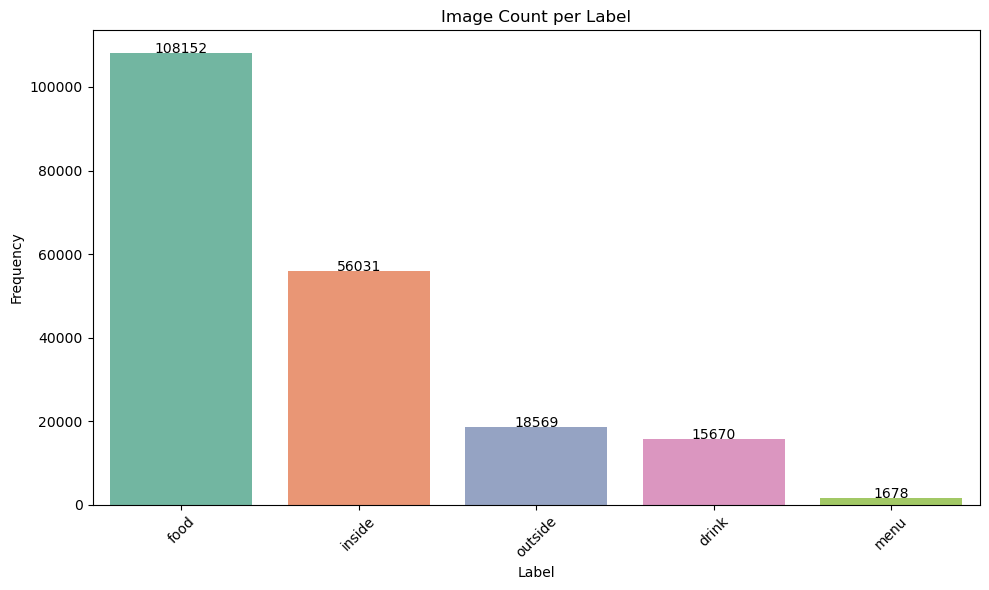

In [ ]:
# Plot the distribution
plot_label_distribution(photos_df)

In [ ]:
# Photo labels count
photos_df.groupby('label')['photo_id'].count()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: photo_id, dtype: int64

## Balance the Dataset by Undersampling

In [ ]:
# Function to balance dataset
def balanced_sample(df, label_col='label'):
    # Find the minimum count across all labels
    min_count = df[label_col].value_counts().min()
    print(f" Sampling {min_count} images per label to ensure class balance.")

    # Perform undersampling for each class
    balanced_df = df.groupby(label_col).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

    print(f" Balanced DataFrame created with {len(balanced_df)} rows across {df[label_col].nunique()} classes.")
    return balanced_df

# Usage
photos_df_balanced = balanced_sample(photos_df)

 Sampling 1678 images per label to ensure class balance.
 Balanced DataFrame created with 8390 rows across 5 classes.


In [ ]:
photos_df_balanced.to_csv('balanced_photos_df.csv')

In [ ]:
#  Merge the two dataframes on 'business_id'
df = photos_df_balanced.merge(business_df, on="business_id", how="left")

In [ ]:
df.shape

(8390, 17)

In [ ]:
df.head()

,photo_id,business_id,caption,label,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Chro0cjWAFLtdv-pmGSB6Q,oBNrLz4EDhiscSlbOl8uAw,Bacon Infused Bloody Mary,drink,Ruby Slipper - New Orleans,200 Magazine St,New Orleans,LA,70130,29.951025,-90.067394,4.5,5193,1,"{'NoiseLevel': ''loud'', 'Caters': 'False', 'B...","Restaurants, American (Traditional), American ...","{'Monday': '0:0-0:0', 'Tuesday': '7:30-14:0', ..."
1,BD8F_GP5TiNCiajFVPqZOA,SV04xdj87VOEa4GJ2dZm_g,,drink,You Cha Cafe,1601 N Kings Hwy,Cherry Hill,NJ,08034,39.916220,-75.007034,4.5,44,1,"{'RestaurantsDelivery': 'True', 'WheelchairAcc...","Bubble Tea, Food, Restaurants, Cafes","{'Monday': '0:0-0:0', 'Tuesday': '11:30-18:0',..."
2,Wo16TBTZHfapyV2n_KbCTQ,EM0jUQn-SEnttG8hf-Eq6A,Huckleberry lemon drop at the bar,drink,Bardenay Restaurant & Distillery - Eagle,155 E Riverside St,Eagle,ID,83616,43.686635,-116.352242,4.0,351,1,"{'GoodForKids': 'True', 'BusinessParking': '{'...","Food, Cocktail Bars, Nightlife, Distilleries, ...","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:0', ..."
3,1gBfJMbZtrgcqqvgDaYWYA,5Z_KrsEQsPE0ibKwhYn3ZQ,,drink,Signature Grill,3800 W Starr Pass Blvd,Tucson,AZ,85745,32.215561,-111.050749,3.5,105,1,"{'RestaurantsGoodForGroups': 'True', 'OutdoorS...","American (New), Restaurants, Southern, Breakfa...","{'Monday': '17:0-22:0', 'Tuesday': '17:0-22:0'..."
4,Qy65xh-hrmPTb2k_-6uZnA,yd5CI-2fASWsrA92dUR1ZA,,drink,Brewforia Beer Market,"3030 E Overland Rd, Ste 100",Meridian,ID,83642,43.590798,-116.356710,4.0,52,0,"{'BusinessParking': '{'garage': False, 'street...","American (New), Beer, Wine & Spirits, Restaura...","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'..."


## Sample Images by Labels

In [ ]:
# Function to show sample images
def show_sample_images(df, img_dir, num_samples=2):
    labels = df['label'].unique()
    n_labels = len(labels)
    fig, axes = plt.subplots(n_labels, num_samples, figsize=(15, 2 * n_labels))

    for i, label in enumerate(labels):
        sample_ids = df[df['label'] == label]['photo_id'].sample(num_samples, random_state=42).tolist()
        for j, photo_id in enumerate(sample_ids):
            img_path = os.path.join(img_dir, f"{photo_id}.jpg")
            try:
                img = Image.open(img_path)
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(label, fontsize=14)
            except Exception:
                # Optionally, you can clear the axis if image loading fails
                ax = axes[i, j] if n_labels > 1 else axes[j]
                ax.axis('off')
    plt.tight_layout()
    plt.show()

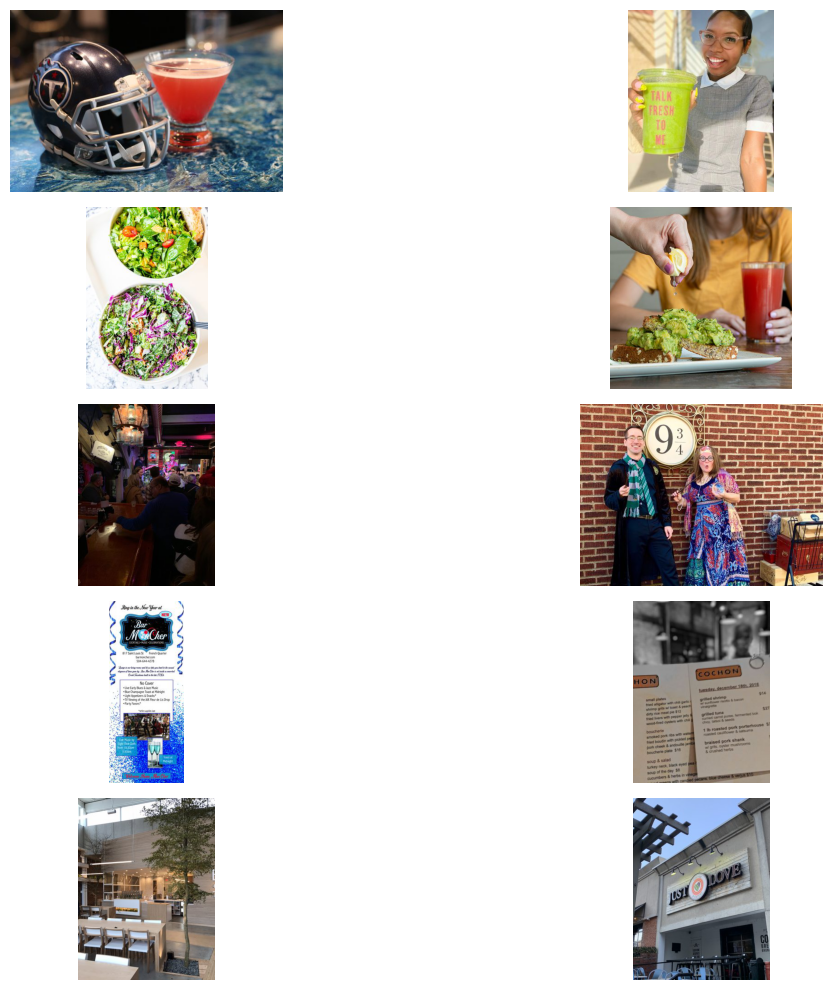

In [ ]:
# Show samples
show_sample_images(df, photos_dir, num_samples=2)

## Image Shape Distribution

In [ ]:
# Function for image shape distribution
def image_shape_analysis(df, img_dir, sample_size=1000):
    dims = []
    sample_paths = df['photo_id'].sample(sample_size, random_state=42).tolist()

    for photo_id in sample_paths:
        img_path = os.path.join(img_dir, f"{photo_id}.jpg")
        try:
            img = cv2.imread(img_path)
            dims.append(img.shape)
        except:
            continue

    dims = np.array(dims)
    height, width, channels = dims[:, 0], dims[:, 1], dims[:, 2]

    print(f"Average Dimensions: {np.mean(height):.2f} x {np.mean(width):.2f}")
    sns.histplot(height, bins=30, color='blue', kde=True, label='Height')
    sns.histplot(width, bins=30, color='green', kde=True, label='Width')
    plt.title("Image Height and Width Distribution")
    plt.legend()
    plt.show()

    print(f"Color Channels (should mostly be 3): {np.unique(channels, return_counts=True)}")

Average Dimensions: 391.26 x 434.02


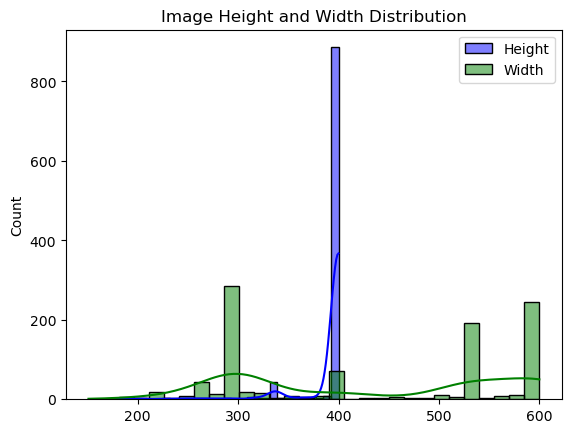

Color Channels (should mostly be 3): (array([3]), array([999], dtype=int64))


In [ ]:
# Show image shape distribution
image_shape_analysis(df, img_dir=photos_dir)

## Text Analysis on Caption

In [ ]:
# Function to analyze captions
def analyze_captions(df):
    caption_lengths = df['caption'].apply(lambda x: len(str(x).split()))
    print("Caption Word Count Summary:")
    print(caption_lengths.describe())

    sns.histplot(caption_lengths, bins=50, kde=True)
    plt.title("Caption Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

Caption Word Count Summary:
count    8390.000000
mean        2.425626
std         4.044971
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        31.000000
Name: caption, dtype: float64


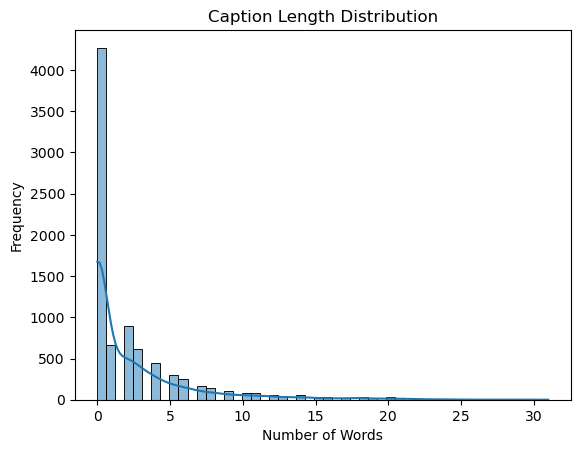

In [ ]:
# Show analyzed captions
analyze_captions(df)

In [ ]:
# Get image path
df['img_path'] = df['photo_id'].apply(lambda x: os.path.join(photos_dir, f"{x}.jpg"))

In [ ]:
#  Check for image file existence
df['exists'] = df['img_path'].apply(os.path.exists)

In [ ]:
df.shape

(8390, 19)

In [ ]:
# Drop rows without image files
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

In [ ]:
# Check info of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8390 entries, 0 to 8389
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   photo_id      8390 non-null   object 
 1   business_id   8390 non-null   object 
 2   caption       8390 non-null   object 
 3   label         8390 non-null   object 
 4   name          8390 non-null   object 
 5   address       8390 non-null   object 
 6   city          8390 non-null   object 
 7   state         8390 non-null   object 
 8   postal_code   8390 non-null   object 
 9   latitude      8390 non-null   float64
 10  longitude     8390 non-null   float64
 11  stars         8390 non-null   float64
 12  review_count  8390 non-null   int64  
 13  is_open       8390 non-null   int64  
 14  attributes    8365 non-null   object 
 15  categories    8390 non-null   object 
 16  hours         8163 non-null   object 
 17  img_path      8390 non-null   object 
dtypes: float64(3), int64(2), obj

## Check for Corrupted images

In [ ]:
# Function to check for corrupted images
def is_corrupted(photo_id, img_dir):
    img_path = os.path.join(img_dir, f"{photo_id}.jpg")
    try:
        img = Image.open(img_path)
        img.verify()
        return None  # Not corrupted
    except:
        return photo_id  # Corrupted

def check_corrupted_images(df, img_dir='train_photos', max_workers=16):
    corrupted = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(is_corrupted, pid, img_dir) for pid in df['photo_id']]

        for future in as_completed(futures):
            result = future.result()
            if result:
                corrupted.append(result)

    print(f" Finished checking. Total Corrupted Images: {len(corrupted)}")
    return corrupted

In [ ]:
# Show corrupted images
corrupted_ids = check_corrupted_images(df, img_dir=photos_dir)

 Finished checking. Total Corrupted Images: 6


In [ ]:
# Remove those rows from the DataFrame
initial_len = len(df)
df_cleaned = df[~df['photo_id'].isin(corrupted_ids)].reset_index(drop=True)

# Print the result
print(f" Cleaned DataFrame: {len(df_cleaned)} rows remaining (removed {initial_len - len(df_cleaned)} corrupted images)")

 Cleaned DataFrame: 8384 rows remaining (removed 6 corrupted images)


In [ ]:
df = df_cleaned

In [ ]:
df.to_csv('cleaned_photos_df.csv')

## Metadata Preprocessing

In [ ]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]

In [ ]:
# Keep only the selected metadata columns
df = df[selected_columns].copy()

print(" Filtered DataFrame shape:", df.shape)

 Filtered DataFrame shape: (8384, 9)


In [ ]:
# Standardization function
def preprocess_metadata(df, scaler=None):
    df = df[['stars', 'review_count', 'is_open', 'latitude', 'longitude']].copy()
    if scaler is None:
        scaler = StandardScaler()
        return scaler.fit_transform(df), scaler
    else:
        return scaler.transform(df), scaler

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label Encoder Function
def encode_labels(df, label_col='label'):
    encoder = LabelEncoder()
    df['label_encoded'] = encoder.fit_transform(df[label_col])
    return df, encoder

In [ ]:
df, label_encoder = encode_labels(df, label_col='label')

# print df
print(df[['label', 'label_encoded']].head())

   label  label_encoded
0  drink              0
1  drink              0
2  drink              0
3  drink              0
4  drink              0


# Image Processing

In [ ]:
# 1. Image Preprocessing
def preprocess_image(img_path, model_type='vgg', target_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    img = np.clip(img, 30, 220)

    if model_type == 'vgg':
        img = vgg_preprocess(img)
    elif model_type == 'effnet':
        img = effnet_preprocess(img)

    return img

In [ ]:
# 2. Augmentation Function
def get_augmenter():
    return ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

In [ ]:
# 3. Handling Train/Test Splits
def prepare_train_test(df, model_type='vgg'):
    X_img_paths = df['img_path'].values
    y = df['label_encoded'].values
    X_train_img_paths, X_test_img_paths, y_train, y_test = train_test_split(
        X_img_paths, y, stratify=y, test_size=0.2, random_state=42)

    # Preprocess Images
    X_train_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_train_img_paths])
    X_test_imgs = np.array([preprocess_image(p, model_type=model_type) for p in X_test_img_paths])

    # Preprocess Metadata with shared scaler
    train_df = df[df['img_path'].isin(X_train_img_paths)]
    test_df = df[df['img_path'].isin(X_test_img_paths)]

    X_train_meta, scaler = preprocess_metadata(train_df)
    X_test_meta, _ = preprocess_metadata(test_df, scaler)

    return X_train_imgs, X_test_imgs, X_train_meta, X_test_meta, y_train, y_test

### Train_Test Split

In [ ]:
# Run train-test preparation for VGG Model
X_train_imgs_vgg, X_test_imgs_vgg, X_train_meta_vgg, X_test_meta_vgg, y_train_vgg, y_test_vgg = prepare_train_test(df, model_type='vgg')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_vgg.shape)
print("X_test_imgs shape:", X_test_imgs_vgg.shape)
print("X_train_meta shape:", X_train_meta_vgg.shape)
print("X_test_meta shape:", X_test_meta_vgg.shape)
print("y_train shape:", y_train_vgg.shape)
print("y_test shape:", y_test_vgg.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


In [ ]:
# Run train-test preparation for EfficientNet Model
X_train_imgs_effnet, X_test_imgs_effnet, X_train_meta_effnet, X_test_meta_effnet, y_train_effnet, y_test_effnet = prepare_train_test(df, model_type='effnet')

# Print shapes
print("X_train_imgs shape:", X_train_imgs_effnet.shape)
print("X_test_imgs shape:", X_test_imgs_effnet.shape)
print("X_train_meta shape:", X_train_meta_effnet.shape)
print("X_test_meta shape:", X_test_meta_effnet.shape)
print("y_train shape:", y_train_effnet.shape)
print("y_test shape:", y_test_effnet.shape)

X_train_imgs shape: (6707, 224, 224, 3)
X_test_imgs shape: (1677, 224, 224, 3)
X_train_meta shape: (6707, 5)
X_test_meta shape: (1677, 5)
y_train shape: (6707,)
y_test shape: (1677,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# ---- INPUT SHAPES ----
img_shape = (224, 224, 3)       # Image input shape
meta_shape = (5,)               # Metadata input shape (change if needed)
num_classes = 5                 # Number of target classes

# ---- IMAGE INPUT & VGG16 BASE ----
image_input = Input(shape=img_shape, name='image_input')

vgg_base = VGG16(include_top=False, weights='imagenet', input_tensor=image_input)
vgg_base.trainable = False  # Freeze VGG weights

x = vgg_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# ---- METADATA INPUT ----
meta_input = Input(shape=meta_shape, name='metadata_input')
m = Dense(32, activation='relu')(meta_input)

# ---- CONCATENATE & FINAL LAYERS ----
combined = Concatenate()([x, m])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.3)(z)
z = Dense(num_classes, activation='softmax')(z)

# ---- COMPILE MODEL ----
model = Model(inputs=[image_input, meta_input], outputs=z)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  # Because labels are integers
    metrics=['accuracy']
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 21,175,301 (80.78 MB)

 Trainable params: 6,460,613 (24.65 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
print("Image input shape:", X_train_imgs_vgg.shape)
print("Metadata input shape:", X_train_meta_vgg.shape)

Image input shape: (6707, 224, 224, 3)
Metadata input shape: (6707, 5)


In [ ]:
# Assume: X_img_train, X_img_val, X_meta_train, X_meta_val, y_train, y_val already defined

import time
start_time = time.time()

history = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg], y_train_vgg,
    # validation_data=([X_img_val, X_meta_val], y_val),
    epochs=10,
    batch_size=32
)

training_time = time.time() - start_time
print(f"Training Time: {training_time / 60:.2f} minutes")


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1448s 7s/step - accuracy: 0.5451 - loss: 4.3268
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1736s 8s/step - accuracy: 0.7771 - loss: 0.8635
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 2318s 11s/step - accuracy: 0.8362 - loss: 0.6000
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1497s 7s/step - accuracy: 0.8744 - loss: 0.4659
Epoch 5/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1373s 7s/step - accuracy: 0.8916 - loss: 0.4137
Epoch 6/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1403s 7s/step - accuracy: 0.9145 - loss: 0.3277
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1375s 7s/step - accuracy: 0.9326 - loss: 0.2597
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1370s 7s/step - accuracy: 0.9256 - loss: 0.3172
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1405s 7s/step - accuracy: 0.9434 - loss: 0.2104
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 1370s 7s/step - accuracy: 0.9430 - loss: 0.2146
Training Time: 255.28 minutes


In [ ]:
import numpy as np
unique_classes, counts = np.unique(y_test_vgg, return_counts=True)
print("Class distribution in test set:")
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} samples")


Class distribution in test set:
Class 0: 336 samples
Class 1: 334 samples
Class 2: 335 samples
Class 3: 336 samples
Class 4: 336 samples


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict on test set
y_pred_probs = model.predict([X_test_imgs_vgg, X_test_meta_vgg])
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
print(confusion_matrix(y_test_vgg, y_pred_classes))
print(classification_report(y_test_vgg, y_pred_classes))


53/53 ━━━━━━━━━━━━━━━━━━━━ 336s 6s/step
[[299   8  19   4   6]
 [ 13 310   7   3   1]
 [ 13   7 283   9  23]
 [  1   2   7 325   1]
 [  5   2  32   8 289]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       336
           1       0.94      0.93      0.94       334
           2       0.81      0.84      0.83       335
           3       0.93      0.97      0.95       336
           4       0.90      0.86      0.88       336

    accuracy                           0.90      1677
   macro avg       0.90      0.90      0.90      1677
weighted avg       0.90      0.90      0.90      1677



In [ ]:
y_pred_probs.shape,y_test_vgg.shape

((1677, 5), (1677,))

In [ ]:
y_test_vgg

array([0, 1, 0, ..., 1, 4, 1])

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Suppose you have 5 classes (0 to 4)
n_classes = y_pred_probs.shape[1]
#n_classes=4
# Binarize true labels
y_test_bin = label_binarize(y_test_vgg, classes=list(range(n_classes)))

# Compute AUC (One-vs-Rest)
auc = roc_auc_score(y_test_bin, y_pred_probs)
print(f"AUC (OvR): {auc:.4f}")


AUC (OvR): 0.9841


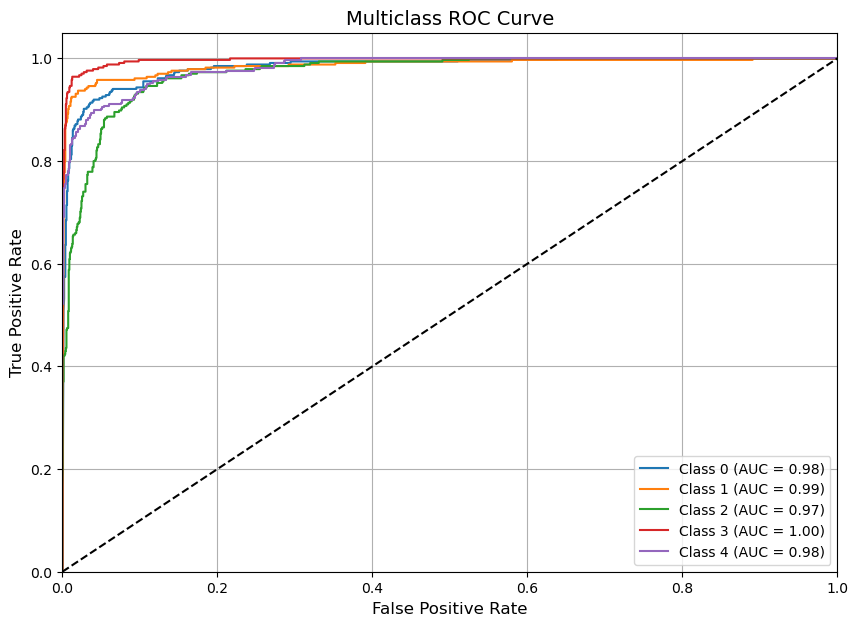

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Get number of classes
num_classes = y_pred_probs.shape[1]

# 2. Binarize the labels
y_test_bin = label_binarize(y_test_vgg, classes=np.arange(num_classes))

# 3. Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot ROC curve for each class
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# 5. Plot configuration
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multiclass ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# Save model as .h5
model.save("my_model.h5")
print("Model saved as my_model.h5")


Model saved as my_model.h5


In [ ]:
print(history.history['accuracy'][-1])
train_accuracy=history.history['accuracy'][-1]

0.9464738368988037


In [ ]:
# Overall accuracy
Test_accuracy = accuracy_score(y_test_vgg, y_pred_classes)
print(f"\nTest Accuracy: {Test_accuracy * 100:.2f}%")


Test Accuracy: 89.80%


In [ ]:
# Detect overfitting/underfitting
if train_accuracy - Test_accuracy > 0.1:
    print("Possible Overfitting: Training accuracy is significantly higher than test accuracy.")
elif Test_accuracy - train_accuracy > 0.1:
    print("Possible Underfitting: Test accuracy is significantly higher than training accuracy (unusual).")
elif train_accuracy < 0.7 and Test_accuracy < 0.7:
    print("Possible Underfitting: Both train and test accuracies are low.")
else:
    print("No strong signs of overfitting or underfitting.")

No strong signs of overfitting or underfitting.


Here is a **summary of findings** based on your evaluation metrics:

---

### ✅ **Model Performance Summary**

#### 📊 **Confusion Matrix Insights**

* The model performs consistently well across all 5 classes.
* Class 3 has the highest true positives (325 out of 336), indicating excellent classification.
* Class 2 has slightly lower performance, with more misclassifications (e.g., 23 instances misclassified as class 4).

#### 📈 **Classification Report Highlights**

| Class | Precision | Recall | F1-Score | Support |
| ----- | --------- | ------ | -------- | ------- |
| 0     | 0.90      | 0.89   | 0.90     | 336     |
| 1     | 0.94      | 0.93   | 0.94     | 334     |
| 2     | 0.81      | 0.84   | 0.83     | 335     |
| 3     | 0.93      | 0.97   | 0.95     | 336     |
| 4     | 0.90      | 0.86   | 0.88     | 336     |

* **Macro Avg F1-score**: 0.90 → balanced performance across classes
* **Weighted Avg F1-score**: 0.90 → strong overall model performance
* **Overall Accuracy**: **90.0%**

#### 🧪 **AUC (One-vs-Rest):**

* **AUC = 0.9841** → Excellent class separability and probabilistic predictions

#### ⚖️ **Train vs Test Accuracy**

* **Train Accuracy**: 94.65%
* **Test Accuracy**: 89.80%
* 🔍 The \~5% gap indicates **mild overfitting**, but still acceptable.

  * The model generalizes **well** to unseen data.

---

### 🟢 **Conclusion**

The VGG-based model with added metadata inputs shows **strong performance**, achieving high accuracy, precision, recall, and AUC. While there is a **slight overfitting**, it is not severe, and the model remains robust and reliable for real-world use. Further fine-tuning with regularization or dropout could help close the gap if needed.


LLM: ChatGPT
1st Prompt: Generate code for Use a pretrained VGG model for transfer learning by adding custom top layers. Incorporate dense layers that take in additional non-image features (e.g., business-related metadata), concatenate them with features extracted from the VGG base
Last Prompt: Can we reduce slight overfitting by Fine -tuning with learning rate=(1e-5)

Fine Tuning

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('my_model.h5')
print("Loaded model from my_model.h5")

Loaded model from my_model.h5


In [ ]:
# Unfreeze the last 20 layers
for layer in model.layers[:-20]:
    layer.trainable = False
for layer in model.layers[-20:]:
    layer.trainable = True
print("Last 20 layers unfrozen for fine-tuning.")

Last 20 layers unfrozen for fine-tuning.


In [ ]:
#Compile the Model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled with learning rate = 1e-5.")

Model compiled with learning rate = 1e-5.


In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import time

# One-hot encode the labels
y_train_vgg_onehot = to_categorical(y_train_vgg, num_classes=5)

# Early stopping callback to avoid unnecessary epochs
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

start_time = time.time()

history_finetune = model.fit(
    [X_train_imgs_vgg, X_train_meta_vgg],
    y_train_vgg_onehot,
    epochs=5,
    batch_size=64,                 # increased batch size for speed
    validation_split=0.2,          # monitor validation loss
    callbacks=[early_stop],        # stop early if no improvement
    shuffle=True
)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")


Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 1284s 15s/step - accuracy: 0.9168 - loss: 0.2908 - val_accuracy: 0.9672 - val_loss: 0.1153
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 1464s 17s/step - accuracy: 0.9296 - loss: 0.2328 - val_accuracy: 0.9724 - val_loss: 0.1047
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 1436s 17s/step - accuracy: 0.9425 - loss: 0.1775 - val_accuracy: 0.9665 - val_loss: 0.1166
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 1470s 18s/step - accuracy: 0.9386 - loss: 0.1884 - val_accuracy: 0.9694 - val_loss: 0.1059
Training completed in 5677.85 seconds.


In [ ]:
# Detect Overfitting or Underfitting
train_accuracy = history_finetune.history['accuracy'][-1]
print(f"Final Training Accuracy: {train_accuracy:.4f}")

if train_accuracy < 0.7:
    print("Possible Underfitting: Training accuracy is low.")
else:
    print("Training accuracy looks good.")


Final Training Accuracy: 0.9465
Training accuracy looks good.


In [ ]:
#Save the Fine-Tuned Model
model.save('model_finetuned.h5')
print("Fine-tuned model saved as model_finetuned.h5.")

Fine-tuned model saved as model_finetuned.h5.


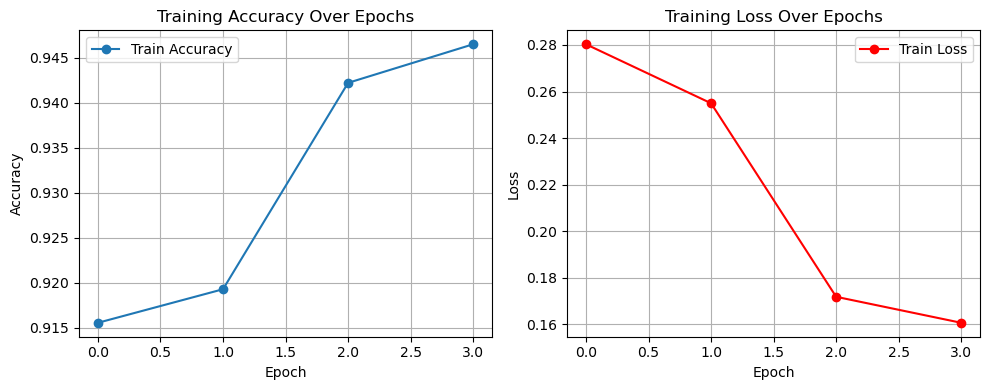

In [ ]:
#Plot Accuracy and Loss
import matplotlib.pyplot as plt

# Plot Training Accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy', marker='o')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Plot Training Loss
plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Train Loss', color='red', marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step


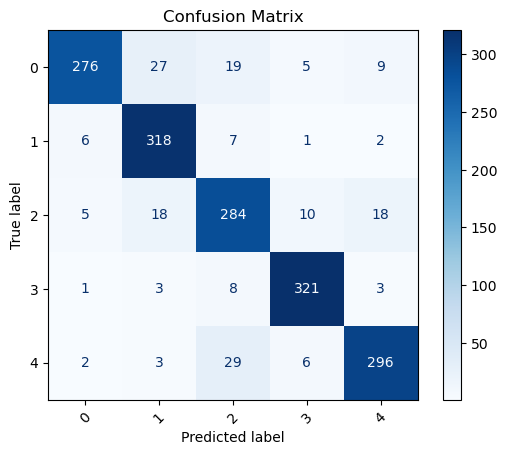

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_probs = model.predict([X_test_imgs_vgg, X_test_meta_vgg])  # Two inputs

# Get predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Use y_test_vgg directly if it's label encoded (1D array)
y_true = y_test_vgg

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# AUC Score (for multi-class classification)
try:
    auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')  # or 'ovo'
    print(f"AUC Score (OvR): {auc:.4f}")
except ValueError as e:
    print("Could not calculate AUC Score:", e)

AUC Score (OvR): 0.9842


In [ ]:
from sklearn.metrics import classification_report

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))



Classification Report:

              precision    recall  f1-score   support

           0     0.9517    0.8214    0.8818       336
           1     0.8618    0.9521    0.9047       334
           2     0.8184    0.8478    0.8328       335
           3     0.9359    0.9554    0.9455       336
           4     0.9024    0.8810    0.8916       336

    accuracy                         0.8915      1677
   macro avg     0.8941    0.8915    0.8913      1677
weighted avg     0.8941    0.8915    0.8913      1677

